<a href="https://colab.research.google.com/github/Md-Golam-Raiyhan/INSE-6450-Smart-Grocery-Assistant/blob/main/restock_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import os, time, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("✅ Setup complete")
print("Torch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

✅ Setup complete
Torch version: 2.10.0+cpu
Device: cpu


In [29]:
import os, shutil

os.makedirs("data", exist_ok=True)
for f in ["pantry.csv","consumption_log.csv","recipes.csv","user_profile.csv"]:
    if os.path.exists(f) and not os.path.exists(os.path.join("data", f)):
        shutil.move(f, os.path.join("data", f))

!ls data

consumption_log.csv  pantry.csv  recipes.csv  user_profile.csv


In [30]:
pantry = pd.read_csv("data/pantry.csv")
consumption = pd.read_csv("data/consumption_log.csv")

items_meta = pantry.set_index("item_id")[["unit","essential"]]

pivot = consumption.pivot_table(index="week", columns="item_id", values="quantity_used")

samples=[]
weeks = sorted(pivot.index.tolist())
for t in weeks:
    if t < 3:
        continue
    for item_id in pivot.columns:
        y = float(pivot.loc[t, item_id])
        last1 = float(pivot.loc[t-1, item_id])
        last2 = float(pivot.loc[t-2, item_id])
        roll2 = (last1 + last2) / 2.0

        unit = items_meta.loc[item_id, "unit"]
        is_piece = 1.0 if unit == "piece" else 0.0
        essential = float(items_meta.loc[item_id, "essential"])

        samples.append({
            "t": t,
            "item_id": int(item_id),
            "last1": last1,
            "last2": last2,
            "roll2": roll2,
            "is_piece": is_piece,
            "essential": essential,
            "y": y
        })

df = pd.DataFrame(samples)
print("Supervised samples:", df.shape)
display(df.head())

Supervised samples: (60, 8)


,t,item_id,last1,last2,roll2,is_piece,essential,y
0,3,1,0.90,0.97,0.935,0.0,1.0,0.95
1,3,2,4.00,4.00,4.000,1.0,1.0,6.00
2,3,3,1.01,1.18,1.095,0.0,1.0,1.08
3,3,4,0.85,0.63,0.740,0.0,0.0,0.47
4,3,5,7.00,1.00,4.000,1.0,1.0,3.00


In [31]:
train_df = df[df["t"].isin([3,4])].copy()
val_df   = df[df["t"]==5].copy()
test_df  = df[df["t"]==6].copy()

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

Train: (30, 8) Val: (15, 8) Test: (15, 8)


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)   # no squared arg
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

baseline_val = eval_metrics(val_df["y"], val_df["roll2"])
baseline_test = eval_metrics(test_df["y"], test_df["roll2"])

print("Baseline (roll2) VAL  MAE/RMSE/R2:", baseline_val)
print("Baseline (roll2) TEST MAE/RMSE/R2:", baseline_test)

Baseline (roll2) VAL  MAE/RMSE/R2: (1.5803333333333331, 2.2671976093847666, 0.3786007888289068)
Baseline (roll2) TEST MAE/RMSE/R2: (1.3503333333333332, 1.8517230714481403, 0.2780473840062345)


In [33]:
class ForecastDS(Dataset):
    def __init__(self, frame):
        self.x = torch.tensor(frame[["last1","last2","roll2","is_piece","essential"]].values, dtype=torch.float32)
        self.y = torch.tensor(frame["y"].values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = ForecastDS(train_df)
val_ds   = ForecastDS(val_df)
test_ds  = ForecastDS(test_df)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [34]:
class GlobalLinear(nn.Module):
    def __init__(self, in_dim=5):
        super().__init__()
        self.lin = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.lin(x)

model = GlobalLinear(in_dim=5)
print(model)
print("Params:", sum(p.numel() for p in model.parameters()))

GlobalLinear(
  (lin): Linear(in_features=5, out_features=1, bias=True)
)
Params: 6


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=5e-2, weight_decay=1e-4)

max_epochs = 500
patience = 50

history = {"train_loss": [], "val_loss": [], "val_mae": []}
best_val = float("inf")
best_state = None
wait = 0

start_total = time.perf_counter()

for epoch in range(1, max_epochs+1):
    # Train
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))

    # Validate
    model.eval()
    val_losses = []
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_losses.append(loss_fn(pred, yb).item())
            y_true.extend(yb.squeeze(1).cpu().numpy().tolist())
            y_pred.extend(pred.squeeze(1).cpu().numpy().tolist())

    val_loss = float(np.mean(val_losses))
    val_mae  = mean_absolute_error(y_true, y_pred)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)

    # Early stopping
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stop at epoch {epoch}")
            break

total_time = time.perf_counter() - start_total
print("Total training time (s):", round(total_time, 4))
print("Avg time/epoch (s):", round(total_time / len(history["train_loss"]), 6))

# Load best model
if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)

Early stop at epoch 52
Total training time (s): 0.1651
Avg time/epoch (s): 0.003175


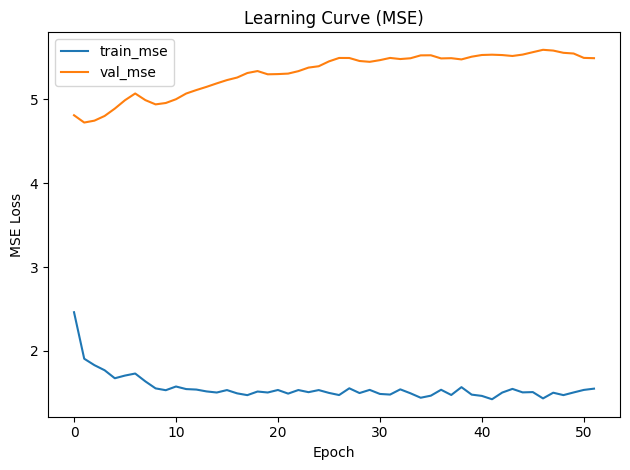

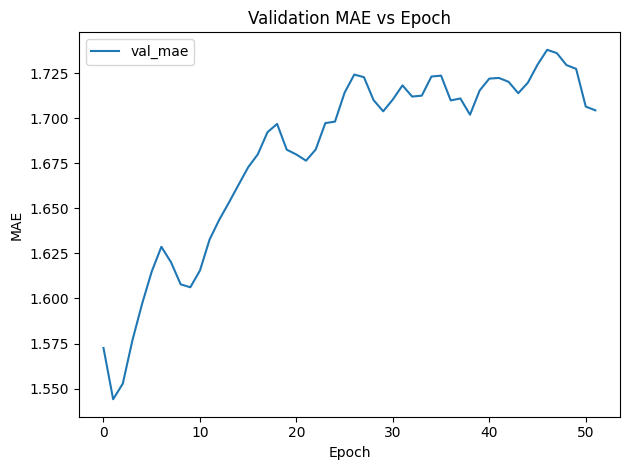

✅ Saved: outputs/learning_curve_mse.png
✅ Saved: outputs/learning_curve_val_mae.png


In [36]:
plt.figure()
plt.plot(history["train_loss"], label="train_mse")
plt.plot(history["val_loss"], label="val_mse")
plt.title("Learning Curve (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/learning_curve_mse.png")
plt.show()

plt.figure()
plt.plot(history["val_mae"], label="val_mae")
plt.title("Validation MAE vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/learning_curve_val_mae.png")
plt.show()

print("✅ Saved: outputs/learning_curve_mse.png")
print("✅ Saved: outputs/learning_curve_val_mae.png")

In [37]:
def predict(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy().reshape(-1)
            ys.extend(yb.numpy().reshape(-1).tolist())
            ps.extend(pred.tolist())
    return np.array(ys), np.array(ps)

val_y, val_p = predict(model, val_loader)
test_y, test_p = predict(model, test_loader)

print("FINAL MODEL VAL  MAE/RMSE/R2:", eval_metrics(val_y, val_p))
print("FINAL MODEL TEST MAE/RMSE/R2:", eval_metrics(test_y, test_p))

FINAL MODEL VAL  MAE/RMSE/R2: (1.5440477599700293, 2.172914887582393, 0.4292086552973341)
FINAL MODEL TEST MAE/RMSE/R2: (1.1880118717749915, 1.641614496197765, 0.4325874005663495)


In [38]:
# Model size
param_count = sum(p.numel() for p in model.parameters())
torch.save(model.state_dict(), "outputs/restock_model.pt")
model_file_size_kb = os.path.getsize("outputs/restock_model.pt") / 1024.0

print("Params:", param_count)
print("Model file size (KB):", round(model_file_size_kb, 4))

# Latency micro-benchmark (per-sample)
def latency_benchmark(model, ds, n_runs=300):
    model.eval()
    # sample up to 50 points
    idxs = np.random.choice(len(ds), size=min(50, len(ds)), replace=False)
    batches = [ds[i][0].unsqueeze(0) for i in idxs]  # x only

    times_ms = []
    with torch.no_grad():
        for _ in range(n_runs):
            xb = random.choice(batches).to(device)
            t0 = time.perf_counter()
            _ = model(xb)
            t1 = time.perf_counter()
            times_ms.append((t1 - t0) * 1000.0)

    times_ms.sort()
    p50 = times_ms[int(0.50 * len(times_ms))]
    p90 = times_ms[int(0.90 * len(times_ms))]
    throughput = 1000.0 / float(np.mean(times_ms))  # samples/sec approx
    return p50, p90, throughput

p50, p90, thr = latency_benchmark(model, test_ds, n_runs=300)
print("Latency p50 (ms):", p50)
print("Latency p90 (ms):", p90)
print("Throughput (samples/sec):", thr)

Params: 6
Model file size (KB): 1.958
Latency p50 (ms): 0.014223999642126728
Latency p90 (ms): 0.018011000065598637
Throughput (samples/sec): 63775.37458001


In [39]:
baseline_val = eval_metrics(val_df["y"], val_df["roll2"])
final_val = eval_metrics(val_y, val_p)

baseline_test = eval_metrics(test_df["y"], test_df["roll2"])
final_test = eval_metrics(test_y, test_p)

results = pd.DataFrame([
    {"split":"val", "model":"baseline_roll2", "MAE":baseline_val[0], "RMSE":baseline_val[1], "R2":baseline_val[2]},
    {"split":"val", "model":"global_linear",  "MAE":final_val[0],    "RMSE":final_val[1],    "R2":final_val[2]},
    {"split":"test","model":"baseline_roll2", "MAE":baseline_test[0],"RMSE":baseline_test[1],"R2":baseline_test[2]},
    {"split":"test","model":"global_linear",  "MAE":final_test[0],   "RMSE":final_test[1],   "R2":final_test[2]},
])
display(results)
results.to_csv("outputs/results_table.csv", index=False)
print("✅ Saved: outputs/results_table.csv")

,split,model,MAE,RMSE,R2
0,val,baseline_roll2,1.580333,2.267198,0.378601
1,val,global_linear,1.544048,2.172915,0.429209
2,test,baseline_roll2,1.350333,1.851723,0.278047
3,test,global_linear,1.188012,1.641614,0.432587


✅ Saved: outputs/results_table.csv
